In [249]:
from glass_sim import *
import scipy as sp
import pickle
from tqdm.notebook import tqdm

## Generate random data ##

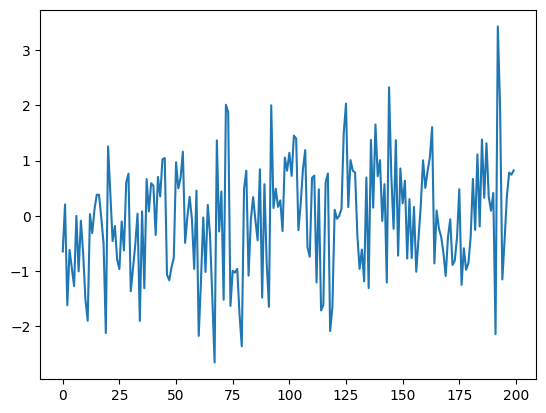

In [250]:
import numpy as np
import matplotlib.pyplot as plt

ndata = 200
nparams = 2

def init_cov(ndim):
    """Initialise random non-diagonal covariance matrix.

    Args:

        ndim: Dimension of Gaussian.

    Returns:

        cov: Covariance matrix of shape (ndim,ndim).

    """

    cov = np.zeros((ndim, ndim))
    diag_cov = np.ones(ndim) + np.random.randn(ndim) * 0.1
    np.fill_diagonal(cov, diag_cov)
    off_diag_size = 0.5
    for i in range(ndim - 1):
        cov[i, i + 1] = (
            (-1) ** i * off_diag_size * np.sqrt(cov[i, i] * cov[i + 1, i + 1])
        )
        cov[i + 1, i] = cov[i, i + 1]

    return cov

#simulates y=ax+b
def mock_simulator(theta):
    theta = np.atleast_2d(theta)
    model_prediction = np.zeros((theta.shape[0], ndata))
    x_grid = np.arange(ndata)
    model_prediction =  theta[:, 0][:, np.newaxis] * x_grid + theta[:, 1][:, np.newaxis]
    return model_prediction 

cov = init_cov(ndata)
theta_truth = [-5, 3]
noiseless_data = mock_simulator(theta_truth)
data = np.random.multivariate_normal(noiseless_data[0], cov)
#plt.plot(np.arange(ndata), noiseless_data)
#plt.plot(np.arange(ndata), data)
plt.plot(np.arange(ndata), data-noiseless_data[0])
plt.show()


## Now let's do some SBI with NLE ##

In [251]:
from sbi.inference import NLE
import torch
means = np.zeros(nparams)
prior_cov = np.diag(np.ones(nparams)*2.0 ** 2)
# Convert to torch tensors
means_torch = torch.tensor(means, dtype=torch.float32)
prior_cov_torch = torch.tensor(prior_cov, dtype=torch.float32)

# Create torch distribution
prior_torch = torch.distributions.MultivariateNormal(means_torch, prior_cov_torch)

In [252]:
nsims = 2000
nrounds = 5
inference = NLE(prior_torch)
proposal = prior_torch
for _ in range(nrounds):
    theta = proposal.sample((nsims,))
    output = mock_simulator(theta.detach().numpy())
    x = x = np.zeros((output.shape[0], output.shape[1]))
    for i in range(output.shape[0]):
        x[i] = np.random.multivariate_normal(output[i], cov)
    x = torch.tensor(x, dtype=torch.float32)
    _ = inference.append_simulations(theta, x).train()
    posterior = inference.build_posterior().set_default_x(torch.tensor(data, dtype=torch.float32))
    proposal = posterior

 Neural network successfully converged after 547 epochs.

/Users/jb/sbi_tutorial/.venv/lib/python3.12/site-packages/sbi/inference/posteriors/mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)
Running vectorized MCMC with 20 chains: 100%|██████████| 7000/7000 [00:02<00:00, 2350.07it/s]


 Neural network successfully converged after 63 epochs.

Running vectorized MCMC with 20 chains: 100%|██████████| 7000/7000 [00:03<00:00, 2311.18it/s]


 Neural network successfully converged after 26 epochs.

Running vectorized MCMC with 20 chains: 100%|██████████| 7000/7000 [00:02<00:00, 2343.86it/s]


 Neural network successfully converged after 65 epochs.

Running vectorized MCMC with 20 chains: 100%|██████████| 7000/7000 [00:03<00:00, 2253.89it/s]


 Neural network successfully converged after 56 epochs.

In [253]:
nle_posterior_theta = posterior.sample((20000,), x=data, num_chains=100)

Running vectorized MCMC with 100 chains: 100%|██████████| 45000/45000 [00:10<00:00, 4496.69it/s]


In [254]:
nle_posterior_samples = nle_posterior_theta.detach().numpy()
nle_posterior_log_probs = posterior.potential(nle_posterior_theta.detach(), x=torch.tensor(data, dtype=torch.float32)).numpy()

## Time to plot

In [255]:
import matplotlib as mpl
def triangle_plot(
    mc_samples,
    truth=None,
    params_to_plot=None,
    savefig=False,
    filename=None,
):
    # Triangle plot
    plt.close()
    # g = plots.getSubplotPlotter(width_inch=12)
    g = plots.getSubplotPlotter()
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.6
    g.settings.axes_fontsize = 18
    g.settings.legend_fontsize = 14
    g.settings.lab_fontsize = 18
    legend = []
    for sample in mc_samples:
        legend.append(sample.getName())
    if params_to_plot:
        g.triangle_plot(
            mc_samples, params=params_to_plot, filled_compare=True, normalized=True, legend_labels=legend,
            constrained_layout=True
        )
    else:
        g.triangle_plot(mc_samples, filled_compare=True, normalized=True, legend_labels=legend, constrained_layout=True)

    if truth is not None:
        g.add_param_markers(truth, color="black", ls="--")

    if savefig:
        plt.savefig(filename, bbox_inches="tight")
    plt.show(block=False)

In [256]:
param_names = [f"theta_{i+1}" for i in range(nparams)]
param_labels = [rf"\theta_{i+1}" for i in range(nparams)]
truth_marker = dict(zip(param_names, [theta_truth[i] for i in range(nparams)]))

In [257]:
from getdist import plots, MCSamples

super_nle_samples = MCSamples(
    samples=nle_posterior_samples,
    names=param_names,
    name_tag="SBI model",
    labels=param_labels,
    label="Super SBI model",
    sampler="mcmc",
)

Removed no burn in


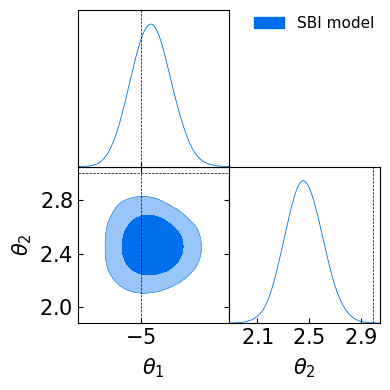

In [258]:
triangle_plot(
    [super_nle_samples],
    truth=truth_marker)